In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller

In [54]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [55]:
data = pd.read_csv('Data/preprocessed/stacked_lmp_price_data.csv')
data.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
data = data[['begin_time', 'NP-15 LMP']]
data['begin_time']=pd.to_datetime(data['begin_time'])
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
390746,2024-12-31 23:35:00,45.51538
390747,2024-12-31 23:40:00,45.51538
390748,2024-12-31 23:45:00,46.04096
390749,2024-12-31 23:50:00,46.04096


In [56]:
data.groupby(data['begin_time']).count().value_counts()

NP-15 LMP
1            390654
2                48
0                 1
Name: count, dtype: int64

In [57]:
data.isna().value_counts()

begin_time  NP-15 LMP
False       False        390750
            True              1
Name: count, dtype: int64

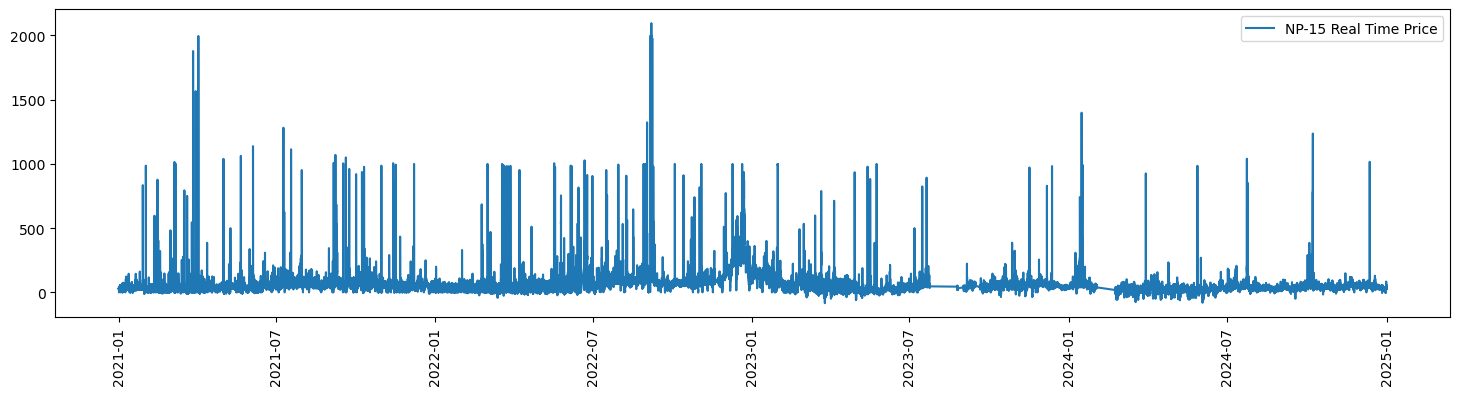

In [58]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP'] , label='NP-15 Real Time Price')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [59]:
print(f'{len(pd.date_range(start=data['begin_time'].min(), end=data['begin_time'].max(), freq='5min'))}')
print(f"{len(data)}")

420768
390751


In [60]:
def process_begin_times(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='5min')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    return df 

In [61]:
data= process_begin_times(data)
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
420763,2024-12-31 23:35:00,45.51538
420764,2024-12-31 23:40:00,45.51538
420765,2024-12-31 23:45:00,46.04096
420766,2024-12-31 23:50:00,46.04096


In [62]:
DailyNANCounts = data.groupby(data['begin_time'].apply(lambda x: x.date())).apply(lambda g: g.isna().sum())
DailyNANCounts.drop(columns=['begin_time'], inplace=True)
DailyNANCounts.reset_index(inplace=True)
DailyNANCounts
DailyNANCounts['NP-15 LMP'].value_counts()

NP-15 LMP
0      995
288     78
2       70
1       68
3       54
4       27
5       26
6       21
8       20
12      17
252     16
10      15
7       14
11      11
9        6
14       3
15       2
108      1
36       1
18       1
254      1
192      1
144      1
20       1
13       1
79       1
17       1
276      1
22       1
240      1
96       1
253      1
98       1
87       1
24       1
Name: count, dtype: int64

In [63]:
data['NP-15 LMP 24hrdiffs'] = data['NP-15 LMP'] - data['NP-15 LMP'].shift(24*12)
data['NP-15 LMP Prev_day_price'] = data['NP-15 LMP'].shift(24*12)

In [65]:
data_15min = data[data['begin_time'].apply(lambda x : x.minute%15==0)].copy()
data_15min

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price
0,2021-01-01 00:00:00,30.76070,NaN,NaN
3,2021-01-01 00:15:00,31.35044,NaN,NaN
6,2021-01-01 00:30:00,32.45147,NaN,NaN
9,2021-01-01 00:45:00,29.98897,NaN,NaN
12,2021-01-01 01:00:00,29.89887,NaN,NaN
...,...,...,...,...
420753,2024-12-31 22:45:00,45.92347,6.20218,39.72129
420756,2024-12-31 23:00:00,46.50217,8.26084,38.24133
420759,2024-12-31 23:15:00,46.25834,7.86632,38.39202
420762,2024-12-31 23:30:00,45.51538,9.08338,36.43200


In [80]:
data_15min['NP-15 LMP'].groupby(data['begin_time'].apply(lambda x: x.hour)).mean()

begin_time
0     57.614622
1     54.257471
2     52.821235
3     52.390074
4     53.607918
5     57.438706
6     62.928346
7     61.940159
8     50.266991
9     46.918699
10    43.600914
11    41.481390
12    40.364110
13    41.214843
14    43.191874
15    45.556265
16    50.728346
17    59.257513
18    70.979310
19    75.276679
20    70.372826
21    69.561120
22    65.552477
23    59.479639
Name: NP-15 LMP, dtype: float64

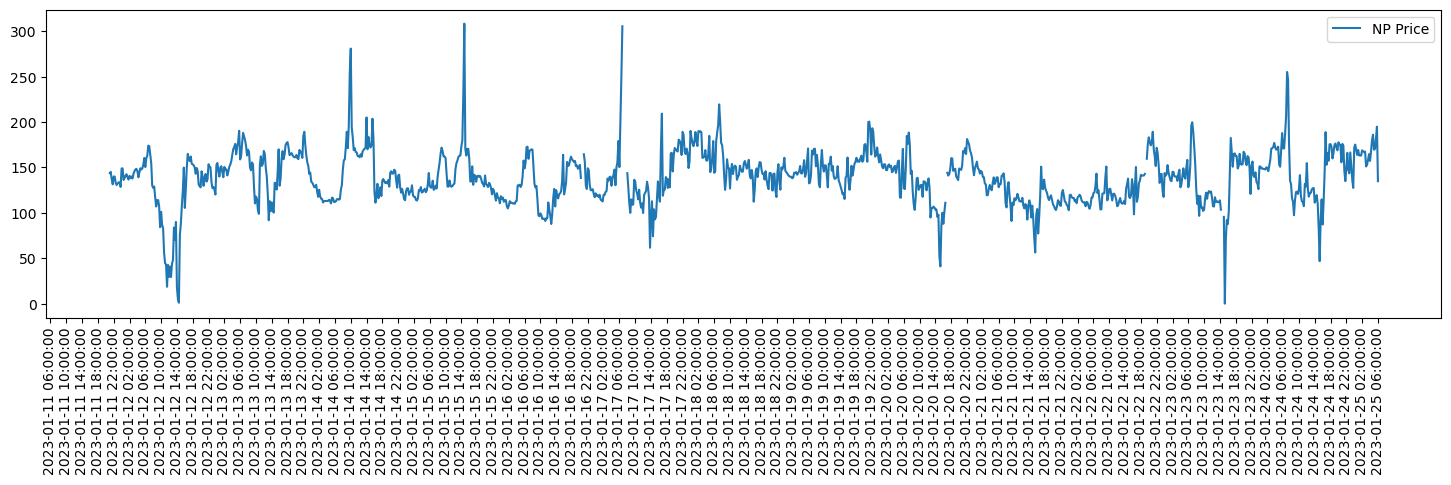

In [66]:
time1 = datetime.datetime(2023, 1, 11, 6, 0, 0)
time2 = datetime.datetime(2023, 1, 25, 6, 0, 0)

filtered_data = data_15min[filter_times(data_15min, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP'] , label='NP Price')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='4h'), labels=pd.date_range(start=time1, end=time2, freq='4h'), rotation=90)
plt.legend()
plt.show()

In [70]:
result = adfuller(data_15min['NP-15 LMP 24hrdiffs'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -34.64407380661819
p-value: 0.0
Critical Values:
   1%: -3.4304016086280584
   5%: -2.861562810258041
   10%: -2.566782141092938


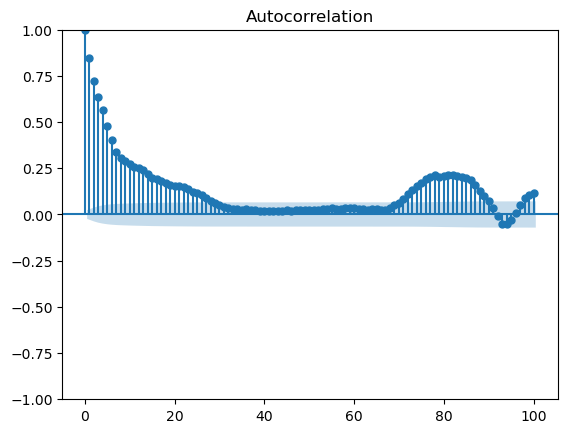

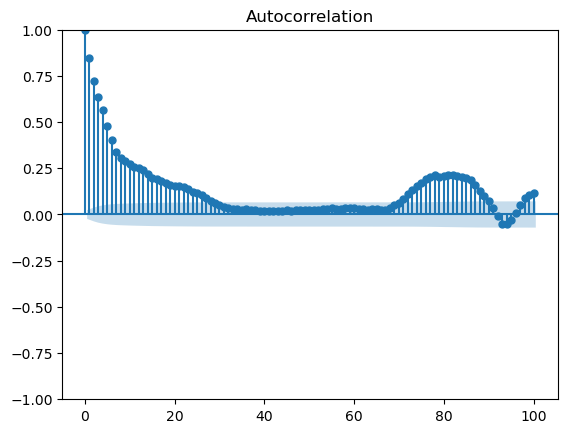

In [73]:
statsmodels.graphics.tsaplots.plot_acf(data_15min['NP-15 LMP 24hrdiffs'].iloc[50000:59000].dropna(), lags=100)

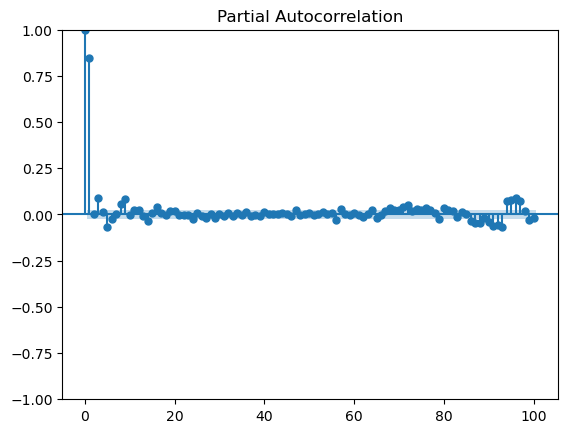

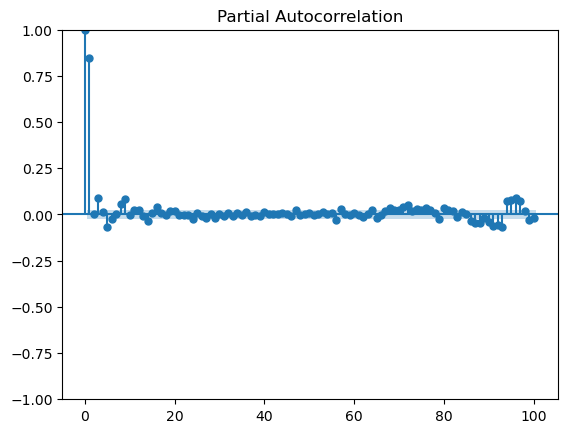

In [69]:
statsmodels.graphics.tsaplots.plot_pacf(data_15min['NP-15 LMP 24hrdiffs'].iloc[50000:59000].dropna(), lags=100)

In [71]:
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(data_15min['NP-15 LMP 24hrdiffs'].iloc[50000:59000].dropna(), nlags=200)

for index, item in enumerate(pacf_values):
    print(f"{index} -> {item}")

0 -> 1.0
1 -> 0.8495117369810522
2 -> 9.74624880308435e-05
3 -> 0.08912501095442851
4 -> 0.011706068742390184
5 -> -0.06953022115860158
6 -> -0.02410228485828329
7 -> 0.002844222276068986
8 -> 0.05825047134054982
9 -> 0.08171146965167764
10 -> -0.0029530166537757676
11 -> 0.023425337925778597
12 -> 0.025043643891478073
13 -> -0.008606459670997138
14 -> -0.03352235972023081
15 -> 0.0063251598221056434
16 -> 0.041238740055572654
17 -> 0.00533093760474977
18 -> -0.003359291152870416
19 -> 0.01758009728055699
20 -> 0.020287573203692497
21 -> -0.0021504379104261965
22 -> -0.002993064764275425
23 -> -0.0023118424931311823
24 -> -0.022084635918893633
25 -> 0.007791672641232522
26 -> -0.007606785765094387
27 -> -0.016874077686069387
28 -> 0.0032531460989669954
29 -> -0.017944636024160354
30 -> 0.005076438723344367
31 -> -0.010586148644049935
32 -> 0.00533908780550253
33 -> -0.005565809721059946
34 -> 0.009510484376757727
35 -> -0.005347737633354251
36 -> 0.012198129947912924
37 -> -0.005947281

In [52]:
data.to_csv('Data/preprocessed/NP15_rt_series.csv', index=False)